# **Customer Churn Prediction using Neural Networks**

"Customer churn" refers to the loss of customers. In business, it's the rate at which customers stop doing business with an entity.

# **Importing Libraries**

In [ ]:
import pandas as pd
import numpy as np

# **Mount Google Drive**

In [ ]:
# Mount Google Drive to access the dataset stored there

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Load The Dataset**

In [ ]:
# Load the churn dataset from Google Drive

df = pd.read_csv('/content/drive/MyDrive/B.Sc /Sem3/Deep learning (NNA)/Churn_Modelling.csv')


In [ ]:
# Display the first few rows to understand the structure
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# Drop unnecessary columns like 'RowNumber', 'CustomerId', and 'Surname' as they don't contribute to the prediction
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace = True)

In [ ]:
# Checking the columns after droping some columns
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# **Data Preprocessing**

In [ ]:
# Check the distribution of values in the 'Geography' column
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [ ]:
# Check the distribution of values in the 'Gender' column
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [ ]:
# Perform one-hot encoding for categorical variables 'Geography' and 'Gender'
# drop_first=True is used to avoid multicollinearity
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True,dtype=int)

In [ ]:
# Display the first few rows of the dataframe after one-hot encoding
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


# **Splitting Data**

In [ ]:
# Separate features (X) and target variable (Y)
X = df.drop(columns=['Exited'])
Y = df['Exited'].values

# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

# **Feature Scaling**

In [ ]:
# Apply StandardScaler to scale the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_trf = scaler.fit_transform(X_train)
X_test_trf = scaler.transform(X_test)

# **Building the Neural Network Model**

In [ ]:
# Import necessary libraries for building the neural network
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
# Create a Sequential model
model = Sequential()

# Add the input layer and the first hidden layer
model.add(Dense(11,activation='sigmoid',input_dim=11))
# Add the second hidden layer
model.add(Dense(11,activation='sigmoid'))
# Add the output layer
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Display the model summary to see the layers and parameters
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

# **Model Compilation**

In [ ]:
# Compile the model
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

# **Model Training**

In [ ]:
# Train the model
history = model.fit(X_train,Y_train,batch_size=50,epochs=100,verbose=1,validation_split=0.2)

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7894 - loss: 0.5141 - val_accuracy: 0.7969 - val_loss: 0.4995
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7976 - loss: 0.5023 - val_accuracy: 0.7969 - val_loss: 0.4998
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7879 - loss: 0.5130 - val_accuracy: 0.7969 - val_loss: 0.4998
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7963 - loss: 0.5044 - val_accuracy: 0.7969 - val_loss: 0.4991
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7993 - loss: 0.5007 - val_accuracy: 0.7969 - val_loss: 0.4992
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7934 - loss: 0.5055 - val_accuracy: 0.7969 - val_loss: 0.4994
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7896 - loss: 0.5113 - val_accuracy: 0.7969 - val_loss: 0.4993
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8078 - loss: 0.4861 - val_accu

# **Model Prediction**

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
# Display the predictions
y_pred

array([[0.24635525],
       [0.24635525],
       [0.23921861],
       ...,
       [0.25048226],
       [0.23921861],
       [0.24635525]], dtype=float32)

In [ ]:
# Convert the predicted probabilities to binary class labels
y_pred = y_pred.argmax(axis=-1)

# **Model Evaluation**

In [ ]:
# Calculate the accuracy score
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,y_pred)

0.7975

# **Visualizing Training History**

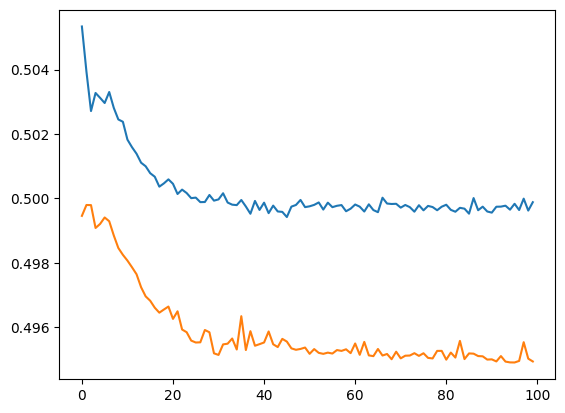

In [ ]:
# Plot the training and validation loss
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

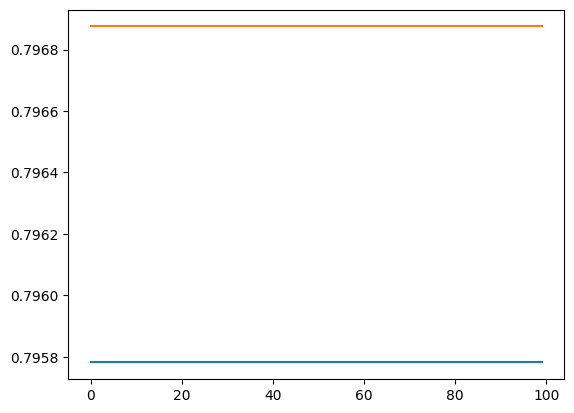

In [ ]:
# Plot the training and validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

# **Conclusion**

Based on the training history and accuracy score, here is a summary of the model's performance:


*   **Accuracy**: The model achieved an accuracy of 79.75% on the test set. This means that the model correctly predicted whether a customer would churn or not for almost 80% of the test data.

*   **Loss**: The training and validation loss decreased over the epochs, suggesting that the model was learning. However, the validation loss appears to level off relatively early, and there is a noticeable gap between the training and validation loss curves, which might indicate some overfitting.

*   **Training History Plots**: The plots show that both training and validation accuracy increased during training, but similar to the loss, the validation accuracy seems to plateau.

Overall, the model shows a reasonable ability to predict churn, but there might be room for improvement by addressing potential overfitting.

